In [1]:
# Importação das bibliotecas necessárias
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

2025-06-25 19:04:07.891908: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-25 19:04:08.292057: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-25 19:04:08.505163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750878248.764646    3690 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750878248.804534    3690 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750878249.356080    3690 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
## carregamento
df=pd.read_csv('../data/diabetes_dataset.csv')

In [3]:
df_teste = df.sample(frac=0.05)

In [4]:
## Limpeza
df.drop('year',axis=1,inplace=True)
df=pd.get_dummies(df,columns=['gender'],drop_first=True)
df['gender_Male']=df['gender_Male'].astype(int)
df['gender_Other']=df['gender_Other'].astype(int)
#df['smoking_history'].unique()

In [5]:
df.head()

,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other
0,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,0,0
1,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,0,0
2,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,1,0
3,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,1,0
4,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,0,0


In [6]:
X=df[['age','hypertension','hbA1c_level','bmi','heart_disease','blood_glucose_level']]
y=df['diabetes']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=101)

In [7]:
## Scalling
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.fit_transform(X_test)

In [8]:
## Training

model = Sequential()
model.add(Dense(units=64, activation="relu")) # Escondida
model.add(Dense(units=32, activation="relu")) # Escondida
model.add(Dense(units=16, activation="relu")) # Escondida
model.add(Dense(units=1, activation="sigmoid"))

model.compile(loss="binary_crossentropy", optimizer="SGD")

2025-06-25 19:04:14.406409: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor="val_loss", mode="min", patience=20)

In [10]:
model.fit(x=X_train, 
          y=y_train, 
          epochs=60, 
          validation_data=(X_test, y_test),
          callbacks=[early_stop])

Epoch 1/60


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2543 - val_loss: 0.1186
Epoch 2/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1179 - val_loss: 0.1146
Epoch 3/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1137 - val_loss: 0.1124
Epoch 4/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1114 - val_loss: 0.1109
Epoch 5/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1108 - val_loss: 0.1089
Epoch 6/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1030 - val_loss: 0.1088
Epoch 7/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1067 - val_loss: 0.1069
Epoch 8/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1066 - val_loss: 0.1045
Epoch 9/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.1052 - val_loss: 0.1038
Epoch 10/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1012 - val_loss: 0.1025
Epoch 11/60
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0979 - val_loss: 0.1013
Epoch 12/60
2188/2188 ━━━━━━━━━━━━━━━━━━━

<Axes: >

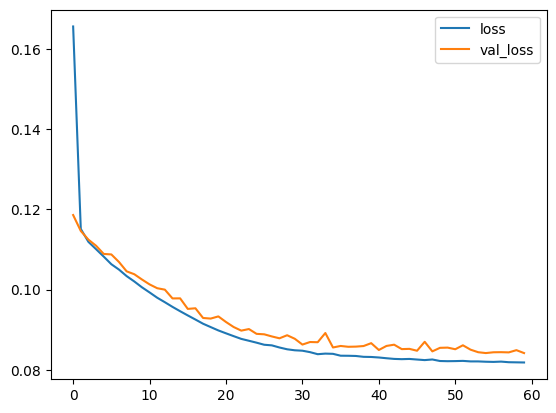

In [11]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()

In [12]:
preds = (model.predict(X_test)).astype("int32")

 76/938 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 728us/step


In [13]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     27422
           1       1.00      0.34      0.51      2578

    accuracy                           0.94     30000
   macro avg       0.97      0.67      0.74     30000
weighted avg       0.95      0.94      0.93     30000



Exemplo de registro:
*  age : 40
*  hypertension : 1
*  hbA1c_leve : 6.5
*  bmi : 28.9
*  heart_disease : 0
*  blood_glucose_level : 166

In [14]:
## Predicting

prediction=(model.predict(scale.transform(np.array([[40,1,6.5,28.9,0,166]])))).astype('int32')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


/workspaces/ml-supervised-dev/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
prediction

array([[0]], dtype=int32)